In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [15]:
x = np.array([50,55,60,70,75,80,90,100])
y = np.array([75,50,90,55,100,60,80,70])

In [16]:
model = np.polyfit(x,y,1)

In [17]:
model

array([ 0.0952381, 65.5952381])

In [18]:
predict = np.poly1d(model)
predict(59)

71.21428571428571

In [19]:
y_pred = predict(x)
y_pred

array([70.35714286, 70.83333333, 71.30952381, 72.26190476, 72.73809524,
       73.21428571, 74.16666667, 75.11904762])

In [20]:
from sklearn.metrics import r2_score
r2_score(y, y_pred)

0.009070294784580657

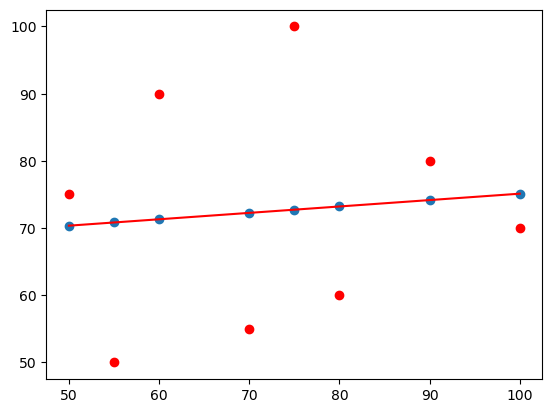

In [21]:
y_line = model[1] + model[0] * x
plt.plot(x,y_line, c = 'r')
plt.scatter(x,y_pred)
plt.scatter(x,y, c = 'r')

In [22]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

In [23]:
california = fetch_california_housing()

In [24]:
df = pd.DataFrame(california.data, columns=california.feature_names)

In [25]:
df['Target'] = california.target

In [26]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64
Mean Squared Error (Training data): 0.5234413607125448
Mean Squared Error (Testing data): 0.5289841670367208


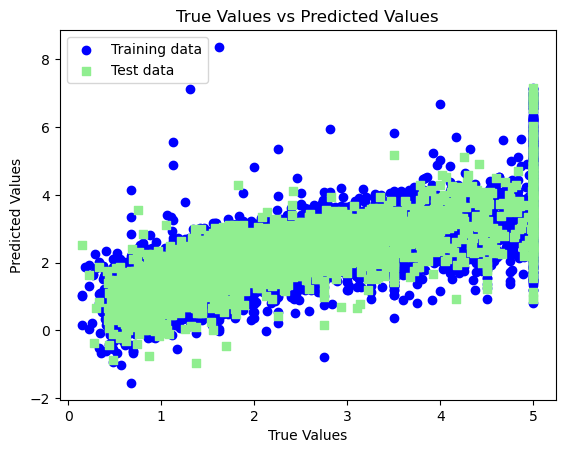

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Import the California Housing dataset
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

# Step 3: Initialize the data frame
data = pd.DataFrame(california.data)

# Step 4: Add the feature names to the dataframe
data.columns = california.feature_names
data.head()

# Step 5: Adding target variable to dataframe
data['PRICE'] = california.target

# Step 6: Perform Data Preprocessing (Check for missing values)
print(data.isnull().sum())

# Step 7: Split dependent variable and independent variables
x = data.drop(['PRICE'], axis=1)
y = data['PRICE']

# Step 8: Splitting data into training and testing datasets
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

# Step 9: Use Linear regression to create the model
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
model = lm.fit(xtrain, ytrain)

# Step 10: Predict the y_pred for all values of train_x and test_x
ytrain_pred = lm.predict(xtrain)
ytest_pred = lm.predict(xtest)

# Step 11: Evaluate the performance of the model for train_y and test_y
df_train = pd.DataFrame({'True Values': ytrain, 'Predicted Values': ytrain_pred})
df_test = pd.DataFrame({'True Values': ytest, 'Predicted Values': ytest_pred})

# Step 12: Calculate Mean Squared Error (MSE) for train_y and test_y
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)

# Output the MSE values
print(f'Mean Squared Error (Training data): {mse_train}')
print(f'Mean Squared Error (Testing data): {mse_test}')

# Step 13: Plotting the Linear Regression model
plt.scatter(ytrain, ytrain_pred, c='blue', marker='o', label='Training data')
plt.scatter(ytest, ytest_pred, c='lightgreen', marker='s', label='Test data')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title("True Values vs Predicted Values")
plt.legend(loc='upper left')
plt.plot()
plt.show()

